# Figure 7D (OFT) — Open-field Test

Exploration-anxiety ratio for the four perinatal-insult groups:
**Sal-N**, **Sal-Hx**, **LPS-N**, **LPS-Hx**.

**Metric.**
$$\text{ratio} = \frac{\text{active-exploring percent}}{\text{safety-seeking percent} + 1}$$
where *safety-seeking* = time in either gate region + time in any chamber
corner; *active-exploring* = remaining time. Adding 1 to the denominator
avoids division by zero when no safety-seeking time is recorded.

**Statistical test.** Pairwise two-sample Welch's t-tests across the four
groups (six pairs). Significance markers: `*` p < 0.05, `**` p < 0.01,
`***` p < 0.001.


In [1]:
import os, re, csv
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from scipy import stats
from IPython.display import display

plt.rcParams["font.family"] = "Arial"

DATA = "data/gabriele_oft_source.csv"

GROUP_ORDER = ["Sal-N", "Sal-Hx", "LPS-N", "LPS-Hx"]
CLS2MODEL   = {"Nx_noPT_noEE":  "Sal-N",
               "Hx_noPT_noEE":  "Sal-Hx",
               "LPS_noPT_noEE": "LPS-N",
               "DH_noPT_noEE":  "LPS-Hx"}
# Paper-wide group palette (matches Fig 6E/F): light box fill + darker dots.
PAL_FILL = {"Sal-N":  "#C6D0E2",   # light periwinkle
            "Sal-Hx": "#7A8FA8",   # mid slate-blue
            "LPS-N":  "#3A4D68",   # dark navy
            "LPS-Hx": "#C8B8BC"}   # dusty mauve
PAL_DOT  = {"Sal-N":  "#4A6FA5",   # mid blue
            "Sal-Hx": "#2C4A6E",   # deep blue
            "LPS-N":  "#0D1F38",   # near-black navy
            "LPS-Hx": "#A55C66"}   # muted rose

CORNER_COLS = [f"Chamber{c}_{p}_time_sec"
               for c in (1, 2, 3)
               for p in ("TopLeft", "TopRight", "BottomLeft", "BottomRight")]

# Exclusions applied to the OFT dataset:
#   - M12023-07-31T11_05_29           : pre-existing tracking failure
#   - control2022-03-14T13_26_27      : OFT counterpart of SIT exclusion 13_41_12
#   - control2022-03-14T14_05_10      : OFT counterpart of SIT exclusion 14_16_43
#   - control2022-03-15T12_35_27      : OFT counterpart of SIT exclusion 12_46_23
EXCLUDE = {
    "M12023-07-31T11_05_29",
    "control2022-03-14T13_26_27",
    "control2022-03-14T14_05_10",
    "control2022-03-15T12_35_27",
}

oft_raw = pd.read_csv(DATA)
oft_raw = oft_raw[oft_raw["Type"] == "OFT"].copy()
oft_raw["group"] = oft_raw["Class"].map(CLS2MODEL)
oft_raw = oft_raw[oft_raw["group"].isin(GROUP_ORDER)].copy()

# After-exclusion working frame
oft = oft_raw[~oft_raw["experiment"].isin(EXCLUDE)].copy()

def compute_ratio(r):
    tot     = float(r["total_time_sec"])
    gate    = float(r["top_gate_time_sec"]) + float(r["bottom_gate_time_sec"])
    corner  = sum(float(r[c]) for c in CORNER_COLS)
    safety  = gate + corner
    explore = tot - safety
    ss_pct  = 100 * safety  / tot
    ae_pct  = 100 * explore / tot
    return ae_pct / (ss_pct + 1)

oft["exploration_anxiety_ratio"] = oft.apply(compute_ratio, axis=1)
oft["group"] = pd.Categorical(oft["group"], categories=GROUP_ORDER, ordered=True)


## OFT — Sample sizes per group (post-exclusion)

In [2]:
n_tab = (oft.groupby("group", observed=True).size()
            .rename("n").reset_index().rename(columns={"group": "Group"}))
n_tab.loc[len(n_tab)] = ["Total", int(n_tab["n"].sum())]
display(n_tab.style.hide(axis="index")
        .set_caption("Per-group sample size in the Fig 7D OFT panel."))


Group,n
Sal-N,5
Sal-Hx,6
LPS-N,5
LPS-Hx,8
Total,24


## OFT — Pairwise Welch's t-tests across the four groups

In [3]:
def stars(p):
    if np.isnan(p):
        return ""
    return ("***" if p < 0.001 else "**" if p < 0.01
            else "*" if p < 0.05 else "ns")

rows = []
for g1, g2 in combinations(GROUP_ORDER, 2):
    a = oft.loc[oft["group"] == g1, "exploration_anxiety_ratio"].to_numpy()
    b = oft.loc[oft["group"] == g2, "exploration_anxiety_ratio"].to_numpy()
    if len(a) < 2 or len(b) < 2:
        p = float("nan")
    else:
        p = stats.ttest_ind(a, b, equal_var=False).pvalue
    rows.append({"g1": g1, "g2": g2,
                 "p_value": f"{p:.4f}" if not np.isnan(p) else "",
                 "stars":   stars(p)})
oft_stats = pd.DataFrame(rows)
display(oft_stats.style.hide(axis="index")
        .set_caption("Pairwise Welch's t-tests on the exploration-anxiety ratio."))


g1,g2,p_value,stars
Sal-N,Sal-Hx,0.0352,*
Sal-N,LPS-N,0.3336,ns
Sal-N,LPS-Hx,0.0316,*
Sal-Hx,LPS-N,0.0334,*
Sal-Hx,LPS-Hx,0.8878,ns
LPS-N,LPS-Hx,0.0295,*


## OFT — Box plot

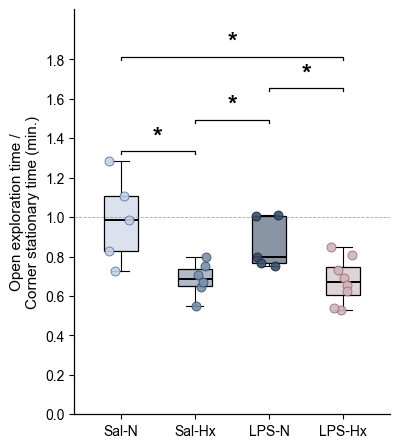

In [4]:
fig, ax = plt.subplots(figsize=(3.8, 5.0), facecolor="white")

box_w = 0.16   # thin boxes per user request
rng = np.random.default_rng(0)

ratios = {g: oft.loc[oft["group"] == g,
                     "exploration_anxiety_ratio"].to_numpy()
          for g in GROUP_ORDER}

# Boxes — solid coloured fill, black outline.
X_POS = [1, 1.35, 1.70, 2.05]   # 0.35 unit spacing -> gap = 0.13 (tighter)
for i, g in enumerate(GROUP_ORDER):
    bp = ax.boxplot([ratios[g]], positions=[X_POS[i]], widths=box_w,
                    patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor=to_rgba(PAL_FILL[g], 0.60),
                                  edgecolor="black", linewidth=0.9),
                    medianprops=dict(color="black", linewidth=1.4),
                    whiskerprops=dict(color="black", linewidth=0.8),
                    capprops=dict(color="black", linewidth=0.8))

    # Individual mice jittered on top.
    vals = ratios[g]
    jitter = rng.uniform(-0.06, 0.06, size=len(vals))
    ax.scatter([X_POS[i] + j for j in jitter], vals,
               marker="o", s=42, facecolor=PAL_FILL[g],
               edgecolor=PAL_DOT[g], linewidth=0.6, alpha=0.90, zorder=3)

# Dashed reference at ratio = 1.
ax.axhline(1.0, linestyle="--", color="gray", linewidth=0.6, alpha=0.7)

# Pairwise brackets (selected: adjacent + Sal-N vs LPS-Hx as in the OneDrive Rmd).
BRACKETS = [("Sal-N",  "Sal-Hx",  1),
            ("Sal-Hx", "LPS-N",   2),
            ("LPS-N",  "LPS-Hx",  3),
            ("Sal-N",  "LPS-Hx",  4)]
y_max_data = float(max(np.max(v) for v in ratios.values()))
y_step = 0.16
y_base = y_max_data + 0.05
for g1, g2, lvl in BRACKETS:
    a = ratios[g1]; b = ratios[g2]
    if len(a) < 2 or len(b) < 2: continue
    p = stats.ttest_ind(a, b, equal_var=False).pvalue
    if np.isnan(p): continue
    x1, x2 = X_POS[GROUP_ORDER.index(g1)], X_POS[GROUP_ORDER.index(g2)]
    y = y_base + (lvl - 1) * y_step
    ax.plot([x1, x1, x2, x2], [y - 0.015, y, y, y - 0.015],
            color="black", linewidth=0.9)
    ax.text((x1 + x2) / 2, y + 0.012,
            "***" if p < 0.001 else "**" if p < 0.01
            else "*" if p < 0.05 else "ns",
            ha="center", va="bottom", fontsize=18, fontweight="bold")

ax.set_xticks(X_POS)
ax.set_xlim(X_POS[0] - 0.22, X_POS[-1] + 0.22)
ax.set_xticklabels(GROUP_ORDER, fontsize=12)
ax.set_ylabel("Open exploration time /\nCorner stationary time (min.)",
              fontsize=11, linespacing=1.15)
ax.set_yticks(np.arange(0, 1.81, 0.2))
ax.set_ylim(0, y_base + len(BRACKETS) * y_step + 0.08)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.spines["left"].set_linewidth(0.9)
ax.spines["bottom"].set_linewidth(0.9)
ax.tick_params(axis="both", labelsize=10)

plt.subplots_adjust(left=0.13, right=0.96, top=0.94, bottom=0.13)
fig.savefig("Fig7D.pdf", bbox_inches="tight")
fig.savefig("Fig7D.png", dpi=300, bbox_inches="tight")
plt.show()


> **Footer.** Brackets show two-sample Welch's t-tests on the
> exploration-anxiety ratio. `*` p < 0.05, `**` p < 0.01, `***` p < 0.001.
> The dashed grey line at *ratio = 1* marks the neutral point at which a
> mouse spends as much time exploring the open zone as it does in the
> corners and gates.
